In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import set_config
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
set_config(transform_output="pandas")

In [4]:
#load in data
sacramento = pd.read_csv("/Users/michelleliu/DSI/LCR/01_materials/notebooks/dataset/sacramento.csv")
sacramento

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,1005 MORENO WAY,SACRAMENTO,95838,CA,3,2,1410,Residential,Fri May 16 00:00:00 EDT 2008,180000,38.646206,-121.442767
1,10105 MONTE VALLO CT,SACRAMENTO,95827,CA,4,2,1578,Residential,Fri May 16 00:00:00 EDT 2008,190000,38.573917,-121.316916
2,10133 NEBBIOLO CT,ELK GROVE,95624,CA,4,3,2096,Residential,Fri May 16 00:00:00 EDT 2008,289000,38.391085,-121.347231
3,10165 LOFTON WAY,ELK GROVE,95757,CA,3,2,1540,Residential,Fri May 16 00:00:00 EDT 2008,266510,38.387708,-121.436522
4,10254 JULIANA WAY,SACRAMENTO,95827,CA,4,2,2484,Residential,Fri May 16 00:00:00 EDT 2008,331200,38.568030,-121.309966
...,...,...,...,...,...,...,...,...,...,...,...,...
808,9507 SEA CLIFF WAY,ELK GROVE,95758,CA,4,2,2056,Residential,Wed May 21 00:00:00 EDT 2008,285000,38.410992,-121.479043
809,9570 HARVEST ROSE WAY,SACRAMENTO,95827,CA,5,3,2367,Residential,Wed May 21 00:00:00 EDT 2008,315537,38.555993,-121.340352
810,9723 TERRAPIN CT,ELK GROVE,95757,CA,4,3,2354,Residential,Wed May 21 00:00:00 EDT 2008,335750,38.403492,-121.430224
811,9837 CORTE DORADO CT,ELK GROVE,95624,CA,4,2,1616,Residential,Wed May 21 00:00:00 EDT 2008,227887,38.400676,-121.381010


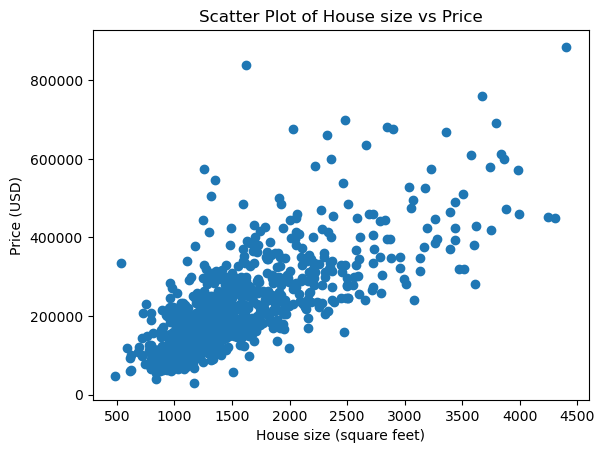

In [5]:
# Plot
plt.scatter(sacramento["sq__ft"], sacramento['price'])

# Add labels and legend
plt.xlabel("House size (square feet)")
plt.ylabel('Price (USD)')
plt.title('Scatter Plot of House size vs Price')
plt.show()

In [8]:
np.random.seed(10)
small_scaramento = sacramento.sample(n=30)
small_scaramento
#select a small subset of the data to see how the data looks



,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
486,7540 HICKORY AVE,ORANGEVALE,95662,CA,3,1,1456,Residential,Thu May 15 00:00:00 EDT 2008,225000,38.703056,-121.235221
399,9013 CASALS ST,SACRAMENTO,95826,CA,2,1,795,Condo,Mon May 19 00:00:00 EDT 2008,126960,38.557045,-121.371670
233,12901 FURLONG DR,WILTON,95693,CA,5,3,3788,Residential,Mon May 19 00:00:00 EDT 2008,691659,38.413535,-121.188211
408,9474 VILLAGE TREE DR,ELK GROVE,95758,CA,4,2,1776,Residential,Mon May 19 00:00:00 EDT 2008,210000,38.413947,-121.408276
549,2901 PINTAIL WAY,ELK GROVE,95757,CA,4,3,3070,Residential,Tue May 20 00:00:00 EDT 2008,495000,38.398488,-121.473424
43,191 BARNHART CIR,SACRAMENTO,95835,CA,4,2,2605,Residential,Fri May 16 00:00:00 EDT 2008,257200,38.675594,-121.515878
181,8316 NORTHAM DR,ANTELOPE,95843,CA,3,2,1235,Residential,Fri May 16 00:00:00 EDT 2008,246544,38.720767,-121.376678
250,2130 CATHERWOOD WAY,SACRAMENTO,95835,CA,3,2,1424,Residential,Mon May 19 00:00:00 EDT 2008,251000,38.675506,-121.510987
140,620 KESWICK CT,GRANITE BAY,95746,CA,4,3,2356,Residential,Fri May 16 00:00:00 EDT 2008,600000,38.732096,-121.219142
392,8593 DERLIN WAY,SACRAMENTO,95823,CA,3,2,1436,Residential,Mon May 19 00:00:00 EDT 2008,180000,38.447585,-121.426627


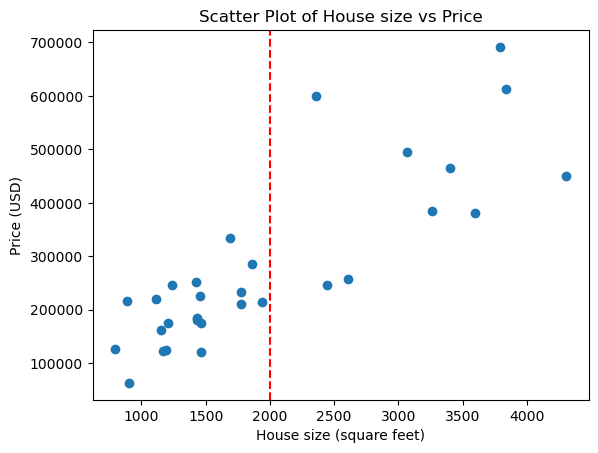

In [10]:
# Plot
plt.scatter(small_scaramento["sq__ft"], small_scaramento['price'])

# Add a vertical line at 2,000 square feet
plt.axvline(x=2000, color='red', linestyle='--', label='2000 sqft')

# Add labels and legend
plt.xlabel("House size (square feet)")
plt.ylabel('Price (USD)')
plt.title('Scatter Plot of House size vs Price')

plt.show()

In [11]:
small_scaramento['dist'] = (2000 - small_scaramento['sq__ft']).abs()

#we subtract the square footage from 2000 to get the distance from 2000 sqft, get absolute value to get the distance


In [12]:
nearest_neighbors = small_scaramento.nsmallest(5, 'dist')

# select the 5 nearest neighbors from the 2000 sqft line
print(nearest_neighbors)



                   street        city    zip state  beds  baths  sq__ft  \
280             3228 I ST  SACRAMENTO  95816    CA     4      3    1939   
197    8986 HAFLINGER WAY   ELK GROVE  95757    CA     3      2    1857   
408  9474 VILLAGE TREE DR   ELK GROVE  95758    CA     4      2    1776   
599         5340 BIRK WAY  SACRAMENTO  95835    CA     3      2    1776   
786     8025 PEERLESS AVE  ORANGEVALE  95662    CA     2      1    1690   

            type                     sale_date   price   latitude   longitude  \
280  Residential  Mon May 19 00:00:00 EDT 2008  215000  38.573844 -121.462839   
197  Residential  Fri May 16 00:00:00 EDT 2008  285000  38.397923 -121.450219   
408  Residential  Mon May 19 00:00:00 EDT 2008  210000  38.413947 -121.408276   
599  Residential  Tue May 20 00:00:00 EDT 2008  234000  38.672495 -121.515251   
786  Residential  Wed May 21 00:00:00 EDT 2008  334150  38.711470 -121.216214   

     dist  
280    61  
197   143  
408   224  
599   224  
78

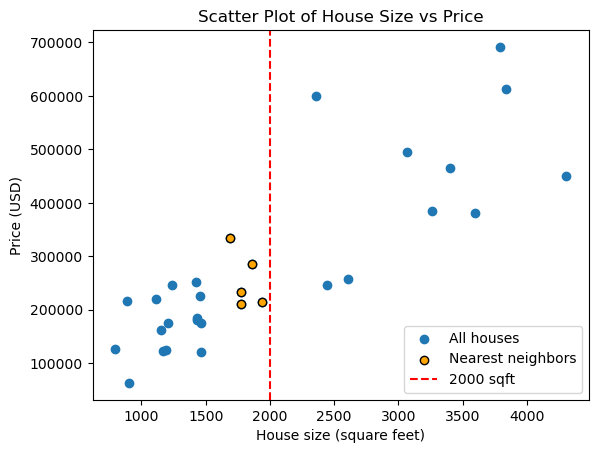

In [14]:
# Scatter plot
plt.scatter(small_scaramento["sq__ft"], small_scaramento['price'], label='All houses')

# Plot nearest neighbors in orange
plt.scatter(nearest_neighbors["sq__ft"], nearest_neighbors['price'], color='orange', label='Nearest neighbors', edgecolor='black')

# Add a vertical line at 2,000 square feet
plt.axvline(x=2000, color='red', linestyle='--', label='2000 sqft')

# Add labels, title, and legend
plt.xlabel("House size (square feet)")
plt.ylabel('Price (USD)')
plt.title('Scatter Plot of House Size vs Price')
plt.legend()

In [15]:
#prediction should be the average price of the nearest neighbors

prediction = nearest_neighbors['price'].mean()
prediction

255630.0

In [20]:
#k is very important, the previous example used k=5, but we can use a different value of k to see how it affects the prediction 
#split the data into training and testing sets

sacramento_train, sacramento_test = train_test_split(sacramento, test_size=0.2, random_state=42, shuffle=True)

#shuffle the data to ensure randomness in the training and testing sets, which are important for categorical variables and regression tasks
# Define the features and target variable

#split training data into x and y
X_train = sacramento_train[['sq__ft']]
y_train = sacramento_train['price']
#split testing data into x and y


In [24]:
#initialize the model

knn_regressor = KNeighborsRegressor()
param_grid = {
    "n_neighbors" : range(1,201,3)
}



In [26]:
#initiate the grid search
sacr_grid_search = GridSearchCV(
    estimator= knn_regressor, 
    param_grid =param_grid,
    cv=5, 
    scoring='neg_mean_squared_error', n_jobs=-1)

#negative mean squared error is used because we want to minimize the error, and GridSearchCV minimizes the score, so we use negative mean squared error to get the best score
# you can also use r2_score, but it is not as useful for regression tasks as mean squared error



In [27]:
#fit our grid search
sacr_grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': range(1, 201, 3)},
             scoring='neg_mean_squared_error')

In [28]:
results =pd.DataFrame(sacr_grid_search.cv_results_)
results


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001597,0.000578,0.001208,0.000888,1,{'n_neighbors': 1},-1.003566e+10,-1.568179e+10,-1.362415e+10,-1.389882e+10,-1.149610e+10,-1.294730e+10,1.971022e+09,67
1,0.001728,0.000960,0.000720,0.000330,4,{'n_neighbors': 4},-6.014550e+09,-9.307695e+09,-1.028288e+10,-8.138993e+09,-9.346999e+09,-8.618225e+09,1.468765e+09,51
2,0.000883,0.000549,0.001148,0.001317,7,{'n_neighbors': 7},-5.744011e+09,-9.240780e+09,-9.422023e+09,-7.722063e+09,-8.344996e+09,-8.094775e+09,1.326841e+09,35
3,0.001338,0.001502,0.000531,0.000097,10,{'n_neighbors': 10},-5.353541e+09,-8.454135e+09,-8.882723e+09,-7.644648e+09,-7.874733e+09,-7.641956e+09,1.223942e+09,13
4,0.001314,0.001634,0.000785,0.000660,13,{'n_neighbors': 13},-5.030268e+09,-8.702369e+09,-9.035925e+09,-7.638467e+09,-7.427855e+09,-7.566977e+09,1.407571e+09,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,0.000821,0.000336,0.002169,0.000465,187,{'n_neighbors': 187},-6.263454e+09,-1.133899e+10,-9.453919e+09,-1.089518e+10,-6.886868e+09,-8.967683e+09,2.059972e+09,63
63,0.000853,0.000272,0.001993,0.000764,190,{'n_neighbors': 190},-6.267777e+09,-1.136768e+10,-9.458310e+09,-1.083356e+10,-6.903458e+09,-8.966156e+09,2.050984e+09,62
64,0.000942,0.000379,0.002110,0.000673,193,{'n_neighbors': 193},-6.309914e+09,-1.144912e+10,-9.489133e+09,-1.087168e+10,-6.925215e+09,-9.009012e+09,2.063081e+09,64
65,0.000662,0.000285,0.001534,0.000457,196,{'n_neighbors': 196},-6.345689e+09,-1.153071e+10,-9.506492e+09,-1.093764e+10,-6.963505e+09,-9.056807e+09,2.078076e+09,65


In [ ]:
results["mean_test_score"] = results["mean_test_score"].abs()
results

#get the absolute value of the mean test score to get the actual mean squared error




,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001597,0.000578,0.001208,0.000888,1,{'n_neighbors': 1},-1.003566e+10,-1.568179e+10,-1.362415e+10,-1.389882e+10,-1.149610e+10,1.294730e+10,1.971022e+09,67
1,0.001728,0.000960,0.000720,0.000330,4,{'n_neighbors': 4},-6.014550e+09,-9.307695e+09,-1.028288e+10,-8.138993e+09,-9.346999e+09,8.618225e+09,1.468765e+09,51
2,0.000883,0.000549,0.001148,0.001317,7,{'n_neighbors': 7},-5.744011e+09,-9.240780e+09,-9.422023e+09,-7.722063e+09,-8.344996e+09,8.094775e+09,1.326841e+09,35
3,0.001338,0.001502,0.000531,0.000097,10,{'n_neighbors': 10},-5.353541e+09,-8.454135e+09,-8.882723e+09,-7.644648e+09,-7.874733e+09,7.641956e+09,1.223942e+09,13
4,0.001314,0.001634,0.000785,0.000660,13,{'n_neighbors': 13},-5.030268e+09,-8.702369e+09,-9.035925e+09,-7.638467e+09,-7.427855e+09,7.566977e+09,1.407571e+09,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,0.000821,0.000336,0.002169,0.000465,187,{'n_neighbors': 187},-6.263454e+09,-1.133899e+10,-9.453919e+09,-1.089518e+10,-6.886868e+09,8.967683e+09,2.059972e+09,63
63,0.000853,0.000272,0.001993,0.000764,190,{'n_neighbors': 190},-6.267777e+09,-1.136768e+10,-9.458310e+09,-1.083356e+10,-6.903458e+09,8.966156e+09,2.050984e+09,62
64,0.000942,0.000379,0.002110,0.000673,193,{'n_neighbors': 193},-6.309914e+09,-1.144912e+10,-9.489133e+09,-1.087168e+10,-6.925215e+09,9.009012e+09,2.063081e+09,64
65,0.000662,0.000285,0.001534,0.000457,196,{'n_neighbors': 196},-6.345689e+09,-1.153071e+10,-9.506492e+09,-1.093764e+10,-6.963505e+09,9.056807e+09,2.078076e+09,65


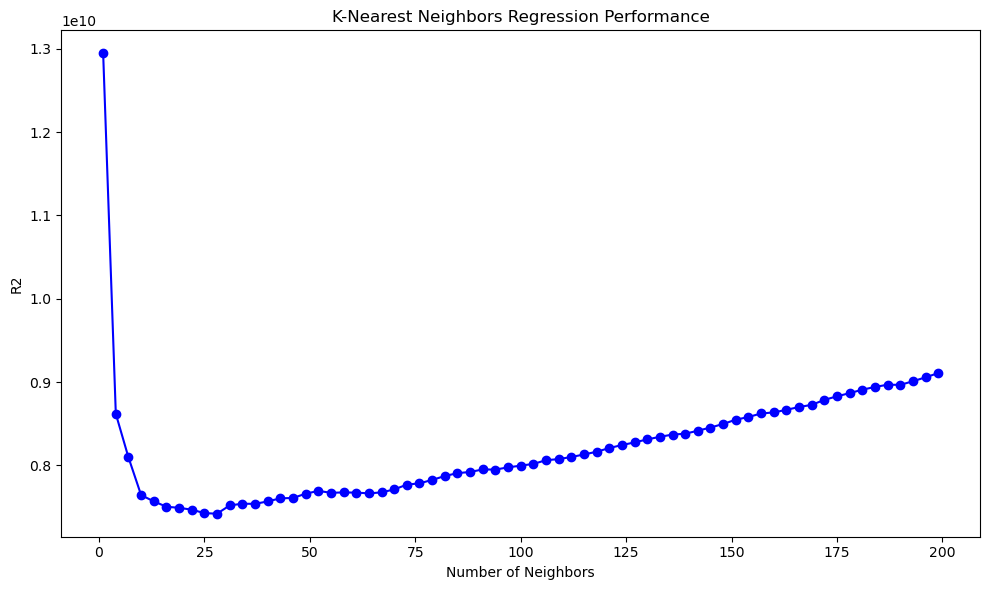

In [31]:
#Create the plot
plt.figure(figsize=(10, 6))

# Plot mean test scores with error bars
plt.plot(results['param_n_neighbors'], results['mean_test_score'], '-o', color='blue')

# Add labels and legend
plt.xlabel('Number of Neighbors')
plt.ylabel('R2')
plt.title('K-Nearest Neighbors Regression Performance')
plt.tight_layout()
plt.show()

In [32]:
sacr_grid_search.best_params_

{'n_neighbors': 28}

In [34]:
#make predictions on the test set
#based on the training set, we found the parameter to be k=28, now we want to see how well the model performs on the test set 

sacramento_test["predicted"] = sacr_grid_search.predict(sacramento_test[['sq__ft']])
# Calculate the mean squared error and R2 score 

rmspe = mean_squared_error(
    y_true=sacramento_test['price'], 
    y_pred=sacramento_test['predicted'])**(1/2)

rmspe

75619.9388081814

In [35]:
r2 = r2_score(
    y_true=sacramento_test['price'], 
    y_pred=sacramento_test['predicted'])
r2

0.49459581945404174

/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


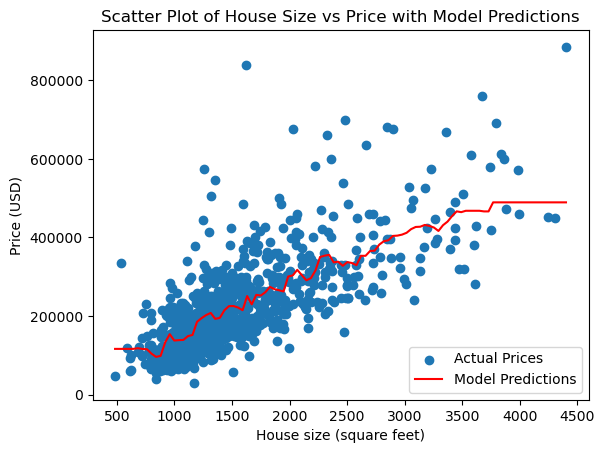

In [37]:

# Generate a range of house sizes for prediction
sizes = np.linspace(sacramento["sq__ft"].min(), sacramento["sq__ft"].max(), 100).reshape(-1, 1)

# Predict house prices for these sizes using the best model from GridSearchCV
predicted_prices = sacr_grid_search.predict(sizes)

# Plot the original data
plt.scatter(sacramento["sq__ft"], sacramento["price"], label="Actual Prices")

# Plot the model predictions as a line
plt.plot(sizes, predicted_prices, color='red', label="Model Predictions")

# Add labels and legend
plt.xlabel("House size (square feet)")
plt.ylabel("Price (USD)")
plt.title("Scatter Plot of House Size vs Price with Model Predictions")
plt.legend()
plt.show();